In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.style
import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.cm as cmx
mpl.style.use('classic')

import baraffe_tables
from baraffe_tables.table_search import baraffe_table_search

from astropy.table import Table
from astropy import units as u
from astropy.constants import G

import mesa_helper as mh
import os
import shutil

%matplotlib inline

In [2]:
mJtomSun = u.jupiterMass.to(u.solMass)
mJtoGrams = u.jupiterMass.to(u.g)

rJtorSun = u.jupiterRad.to(u.solRad)
rSuntorJ = u.solRad.to(u.jupiterRad)
rJtoCm = u.jupiterRad.to(u.cm)

#print(mJtomSun)
print(20.0*mJtoGrams)
#print(rJtorSun)
print(2*rJtoCm)


3.796249194672101e+31
14298400000.0


In [3]:
eos_choices = ['MESA_default','CD21+AQUA_orig_meos_implementation','CMS19_orig_1st_implementation','CMS19_orig_meos_implementation','CMS19_TC_s=1','CMS19_control_s=1_sf=0.05','CMS19_control_s=1_sf=0.1','CMS19_control_s=1_sf=0.25','CMS19_TC_s=2','CMS19_control_s=2_sf=0.05','CMS19_control_s=2_sf=0.1','CMS19_control_s=2_sf=0.25']

#eos_choices = ['MESA_default','CMS19_orig_meos_implementation','CMS19_TC_s=1','CMS19_control_s=1_sf=0.25']

colors = ['k','m','b','r','g','g','g','g','y','y','y','y']
ls = ['-','-','-','-','-','--','-.',':','-','--','-.',':']
#colors=['k','b','r','r']
#ls=['-','-','-',':']
print(eos_choices)

comps = ['00z90x','protosolar']
#Minit = np.array((20.0,10.0,7.5,6.0,5.0,4.0,3.0,2.0))
Minit = np.array((20.0,10.0,5.0,2.0,1.0))

#comps = ['platowg']
#Minit = np.atleast_1d(np.array((1.0)))


['MESA_default', 'CD21+AQUA_orig_meos_implementation', 'CMS19_orig_1st_implementation', 'CMS19_orig_meos_implementation', 'CMS19_TC_s=1', 'CMS19_control_s=1_sf=0.05', 'CMS19_control_s=1_sf=0.1', 'CMS19_control_s=1_sf=0.25', 'CMS19_TC_s=2', 'CMS19_control_s=2_sf=0.05', 'CMS19_control_s=2_sf=0.1', 'CMS19_control_s=2_sf=0.25']


no mespa for 1.0


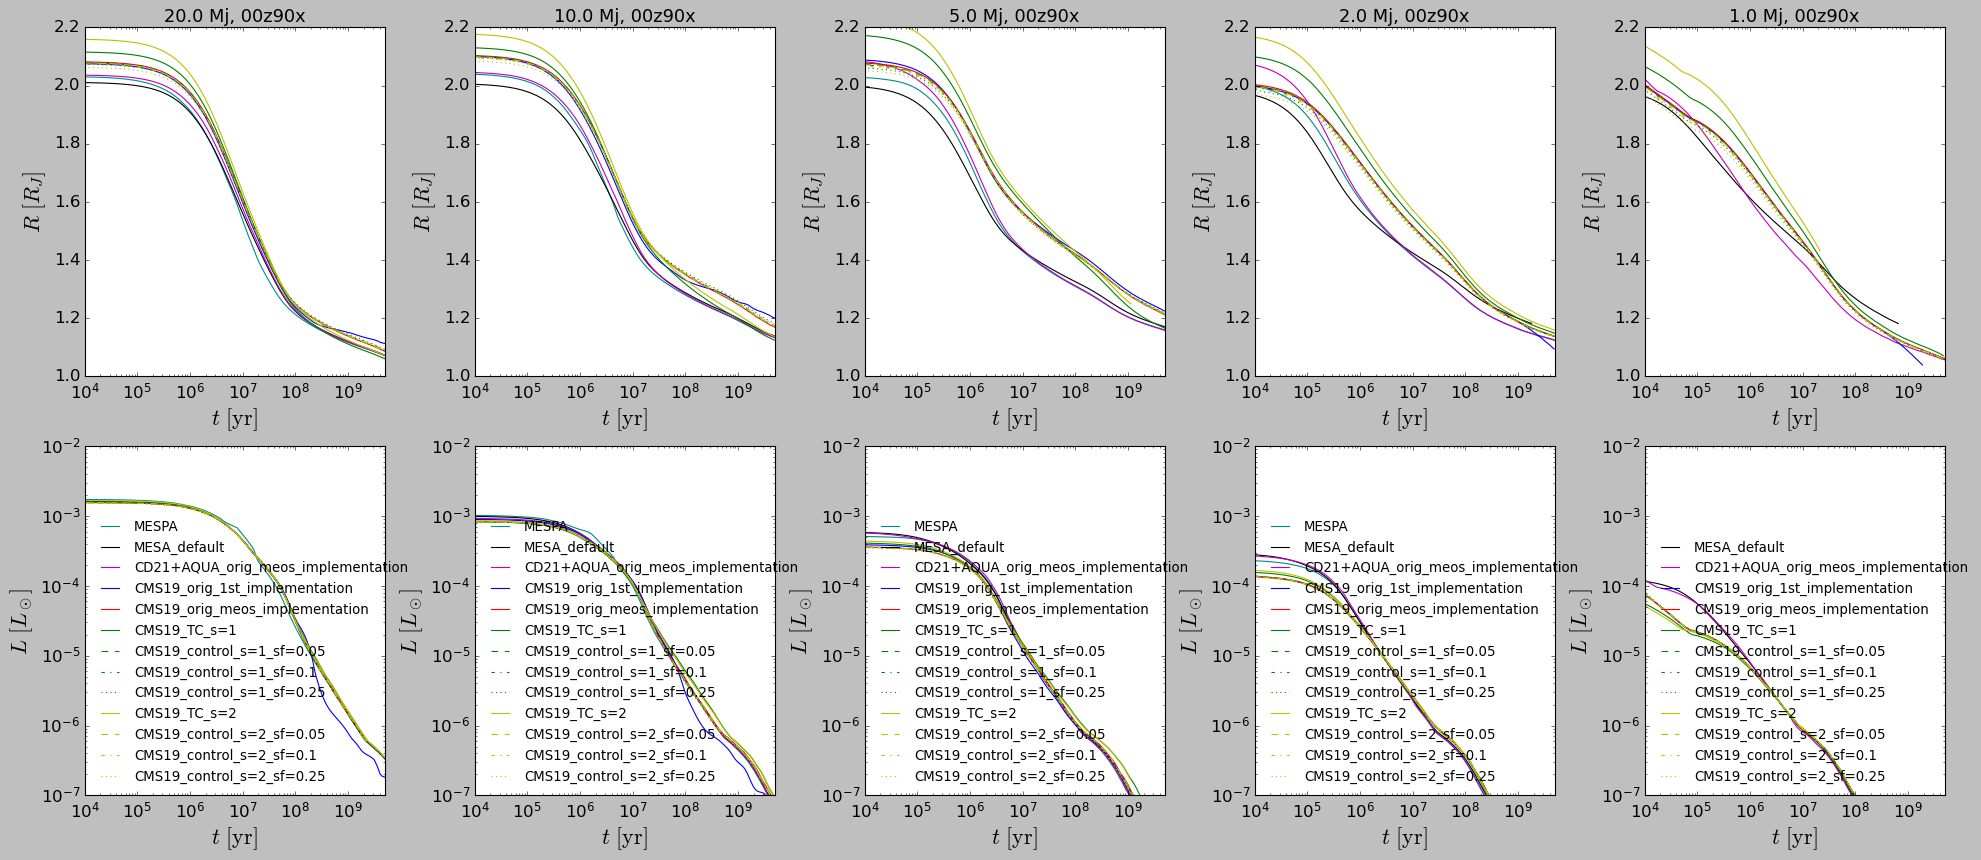

In [4]:
#fig, axes = plt.subplots(3,len(Minit),figsize=(24,16))
fig, axes = plt.subplots(2,len(Minit),figsize=(6*len(Minit),6*2))
for ii in range(len(Minit)):
    axes[0,ii].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
    axes[0,ii].set_ylabel(r"$R\ [R_J]$",fontsize=20)
    axes[1,ii].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
    axes[1,ii].set_ylabel(r"$L\ [L_\odot]$",fontsize=20)
    #axes[2,ii].set_xlabel(r"$\log_{10}T\ [\mathrm{K}]$",fontsize=20)
    #axes[2,ii].set_ylabel(r"$\log_{10}P\ [\mathrm{bar}]$",fontsize=20)
    
    axes[0,ii].set_xscale('log')
    axes[1,ii].set_xscale('log')
    axes[1,ii].set_yscale('log')
    axes[0,ii].set_xlim(1.e4,5.e9)
    axes[0,ii].set_ylim(1.,2.2)
    axes[1,ii].set_xlim(1.e4,5.e9)
    axes[1,ii].set_ylim(1.e-7,1.e-2)
    
    #axes[2,ii].invert_yaxis()

for ax in np.ravel(axes):
    ax.tick_params(axis='both', which='major', labelsize=15)

for j, m in enumerate(Minit):
    for k, comp in enumerate(comps[0:1]):
        axes[0,j].set_title("{0} Mj, {1}".format(m,comp),fontsize=16)
        try:     
            history_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/LOGS/planet_5.0Gyr_{0}_Mj_{1}_mespa.history".format(m,comp)
            
            history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
        
            axes[0,j].plot(history['star_age'],history['radius']*rSuntorJ,color='#008B8B',ls='-')
            axes[1,j].plot(history['star_age'],history['luminosity'],color='#008B8B',ls='-',label='MESPA')
            '''
            profile_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/planet_5.0Gyr_{0}_Mj_{1}_mespa.profile".format(m,comp)
            
            profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
        
            axes[2,j].plot(profile['logT'],profile['logP']-6,color='#008B8B',ls='-',label='MESPA')
            '''
        except FileNotFoundError:
            print("no mespa for {0}".format(m))
    
        for i,e in enumerate(eos_choices):

            try:
                history_filename = "./eos_{0}/planet_5.0Gyr_{1}_Mj_{2}.history".format(e,m,comp)
                history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
    
                axes[0,j].plot(history['star_age'],history['radius']*rSuntorJ,color=colors[i],ls=ls[i])
                axes[1,j].plot(history['star_age'],history['luminosity'],color=colors[i],ls=ls[i],label=e)

                #print(e)
                #print(history['radius']*rSuntorJ)
                #print(history['luminosity'])
                '''
                profile_filename = "./eos_{0}/planet_1.0Gyr_{1}_Mj_{2}.profile".format(e,m,comp)
                profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
    
                axes[2,j].plot(profile['logT'],profile['logP']-6,color=colors[i],ls=ls[i],label=e)
                '''
                axes[1,j].legend(loc='lower left',frameon=False,fontsize=12)
            except FileNotFoundError:
                print("no {0}".format(e))
            
plt.subplots_adjust(hspace=0.2,wspace=0.3)
plt.show()

In [5]:
# eos names
eos_names = ['MESA_default','CD21+AQUA_orig_meos_implementation','CMS19_orig_meos_implementation','CMS19_TC_s=1','CD21_Y0275']
comps = ['platowg']

Minit = np.atleast_1d(np.array((1.0)))

age = 5.0e9
agestr = str(np.round(age/1.e9, 1))
print(agestr)

5.0


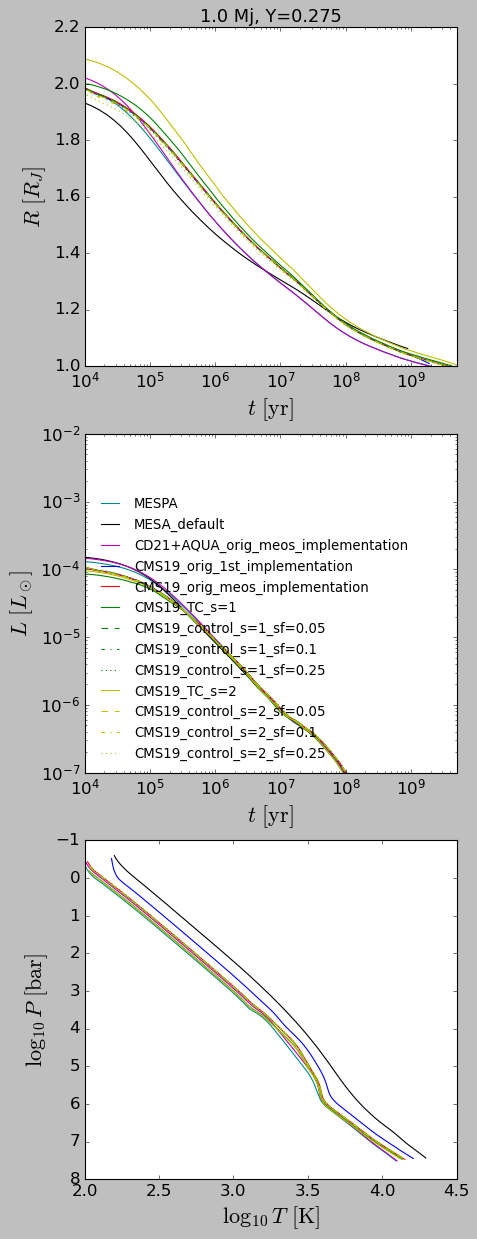

In [8]:
# for Jupiter models

fig, axes = plt.subplots(3,1,figsize=(6,18))
axes[0].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
axes[0].set_ylabel(r"$R\ [R_J]$",fontsize=20)
axes[1].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
axes[1].set_ylabel(r"$L\ [L_\odot]$",fontsize=20)
axes[2].set_xlabel(r"$\log_{10}T\ [\mathrm{K}]$",fontsize=20)
axes[2].set_ylabel(r"$\log_{10}P\ [\mathrm{bar}]$",fontsize=20)
    
axes[0].set_xscale('log')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[0].set_xlim(1.e4,5.e9)
axes[0].set_ylim(1.,2.2)
axes[1].set_xlim(1.e4,5.e9)
axes[1].set_ylim(1.e-7,1.e-2)
    
axes[2].invert_yaxis()

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=15)

for k, comp in enumerate(comps):
    axes[0].set_title("1.0 Mj, Y=0.275",fontsize=16)
    try:     
        history_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/LOGS/planet_5.0Gyr_1.0_Mj_{0}_mespa.history".format(comp)
            
        history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
        
        axes[0].plot(history['star_age'],history['radius']*rSuntorJ,color='#008B8B',ls='-')
        axes[1].plot(history['star_age'],history['luminosity'],color='#008B8B',ls='-',label='MESPA')
        
        profile_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/planet_5.0Gyr_1.0_Mj_{0}_mespa.profile".format(comp)
            
        profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
        
        axes[2].plot(profile['logT'],profile['logP']-6,color='#008B8B',ls='-',label='MESPA')
        
    except FileNotFoundError:
        print("no mespa for {0}".format(m))
    
    for i,e in enumerate(eos_choices):

        try:
            history_filename = "./eos_{0}/planet_5.0Gyr_1.0_Mj_{1}_equallyspacedgrid.history".format(e,comp)
            history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
    
            axes[0].plot(history['star_age'],history['radius']*rSuntorJ,color=colors[i],ls=ls[i])
            axes[1].plot(history['star_age'],history['luminosity'],color=colors[i],ls=ls[i],label=e)

            profile_filename = "./eos_{0}/planet_5.0Gyr_1.0_Mj_{1}_equallyspacedgrid.profile".format(e,comp)
            profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
    
            axes[2].plot(profile['logT'],profile['logP']-6,color=colors[i],ls=ls[i],label=e)

            axes[1].legend(loc='lower left',frameon=False,fontsize=12)
        except FileNotFoundError:
            print("no {0}".format(e))
            
plt.subplots_adjust(hspace=0.2,wspace=0.3)
plt.show()

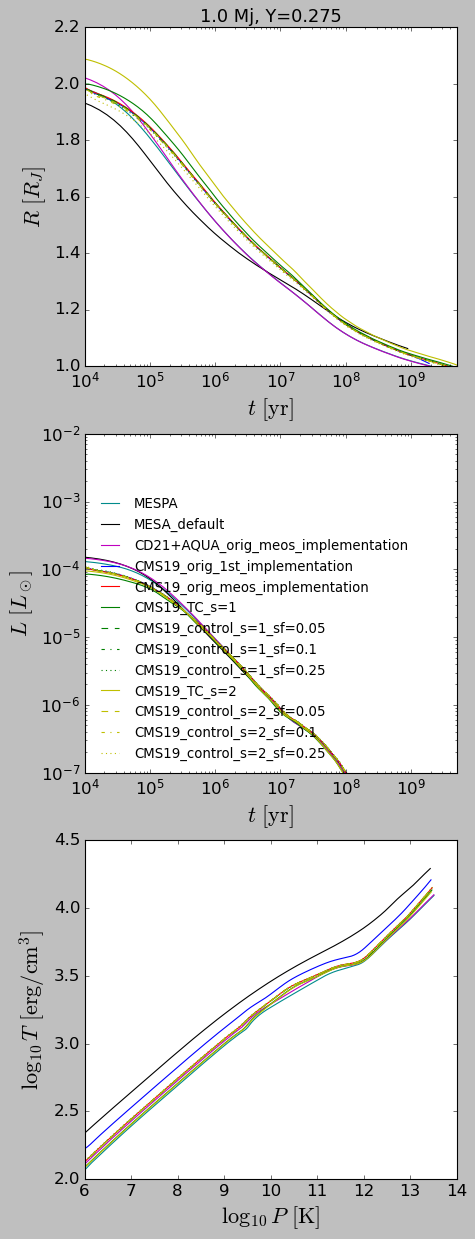

In [9]:
# for Jupiter models

fig, axes = plt.subplots(3,1,figsize=(6,18))
axes[0].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
axes[0].set_ylabel(r"$R\ [R_J]$",fontsize=20)
axes[1].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
axes[1].set_ylabel(r"$L\ [L_\odot]$",fontsize=20)
axes[2].set_xlabel(r"$\log_{10}P\ [\mathrm{K}]$",fontsize=20)
axes[2].set_ylabel(r"$\log_{10}T\ [\mathrm{erg/cm^3}]$",fontsize=20)
    
axes[0].set_xscale('log')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[0].set_xlim(1.e4,5.e9)
axes[0].set_ylim(1.,2.2)
axes[1].set_xlim(1.e4,5.e9)
axes[1].set_ylim(1.e-7,1.e-2)
axes[2].set_xlim(6.,14.)
axes[2].set_ylim(2.0,4.5)

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=15)

for k, comp in enumerate(comps):
    axes[0].set_title("1.0 Mj, Y=0.275",fontsize=16)
    try:     
        history_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/LOGS/planet_5.0Gyr_1.0_Mj_{0}_mespa.history".format(comp)
            
        history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
        
        axes[0].plot(history['star_age'],history['radius']*rSuntorJ,color='#008B8B',ls='-')
        axes[1].plot(history['star_age'],history['luminosity'],color='#008B8B',ls='-',label='MESPA')
        
        profile_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/planet_5.0Gyr_1.0_Mj_{0}_mespa.profile".format(comp)
            
        profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
        
        axes[2].plot(profile['logP'],profile['logT'],color='#008B8B',ls='-',label='MESPA')
        
    except FileNotFoundError:
        print("no mespa for {0}".format(m))
    
    for i,e in enumerate(eos_choices):

        try:
            history_filename = "./eos_{0}/planet_5.0Gyr_1.0_Mj_{1}_equallyspacedgrid.history".format(e,comp)
            history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
    
            axes[0].plot(history['star_age'],history['radius']*rSuntorJ,color=colors[i],ls=ls[i])
            axes[1].plot(history['star_age'],history['luminosity'],color=colors[i],ls=ls[i],label=e)

            profile_filename = "./eos_{0}/planet_5.0Gyr_1.0_Mj_{1}_equallyspacedgrid.profile".format(e,comp)
            profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
    
            axes[2].plot(profile['logP'],profile['logT'],color=colors[i],ls=ls[i],label=e)

            axes[1].legend(loc='lower left',frameon=False,fontsize=12)
        except FileNotFoundError:
            print("no {0}".format(e))
            
plt.subplots_adjust(hspace=0.2,wspace=0.3)
plt.show()